In [ ]:
# ============================================================
# 🍃 Guava Disease Classification using ResNet50 (3 Classes)
# ============================================================

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ============================================================
# Dataset Paths (Update these paths)
# ============================================================
train_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\GuavaDiseaseDataset\train"
val_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\GuavaDiseaseDataset\val"
test_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\GuavaDiseaseDataset\test"

# ============================================================
# Parameters
# ============================================================
img_size = (224, 224)
batch_size = 32
num_classes = 3

# ============================================================
# Data Generators
# ============================================================
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

# ============================================================
# Model Definition — ResNet50
# ============================================================
tf.keras.backend.clear_session()

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze convolutional base
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ============================================================
# Compile Model
# ============================================================
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# Callbacks
# ============================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_resnet50_guava_disease.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

# ============================================================
# Training
# ============================================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

# ============================================================
# Evaluation
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")

# ============================================================
# Save Final Model
# ============================================================
model.save("resnet50_guava_disease_final.h5")

# ============================================================
# Plot Accuracy Curves
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('ResNet50 Guava Disease Classification Accuracy')
plt.show()

TensorFlow Version: 2.20.0
⚠️ No GPU detected — running on CPU. Check CUDA & cuDNN installation.
Found 3091 images belonging to 3 classes.
Found 926 images belonging to 3 classes.
Found 473 images belonging to 3 classes.

✅ Detected 3 classes: ['Anthracnose_augmented', 'fruit_fly_augmented', 'healthy_guava_augmented']
Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3572 - loss: 1.4075
Epoch 1: val_accuracy improved from None to 0.39093, saving model to best_resnet50_guava_disease.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.3436 - loss: 1.3117 - val_accuracy: 0.3909 - val_loss: 1.0922 - learning_rate: 1.0000e-04
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3614 - loss: 1.1897
Epoch 2: val_accuracy improved from 0.39093 to 0.42117, saving model to best_resnet50_guava_disease.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.3633 - loss: 1.1819 - val_accuracy: 0.4212 - val_loss: 1.0721 - learning_rate: 1.0000e-04
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3576 - loss: 1.1557
Epoch 3: val_accuracy improved from 0.42117 to 0.43844, saving model to best_resnet50_guava_disease.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.3701 - loss: 1.1432 - val_accuracy: 0.4384 - val_loss: 1.0507 - learning_rate: 1.0000e-04
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4309 - loss: 1.0994
Epoch 4: val_accuracy improved from 0.43844 to 0.52268, saving model to best_resnet50_guava_disease.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.4238 - loss: 1.0955 - val_accuracy: 0.5227 - val_loss: 1.0310 - learning_rate: 1.0000e-04
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4297 - loss: 1.0764
Epoch 5: val_accuracy improved from 0.52268 to 0.53456, saving model to best_resnet50_guava_disease.h5


...

97/97 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.7286 - loss: 0.7224 - val_accuracy: 0.7743 - val_loss: 0.7454 - learning_rate: 1.0000e-04
Epoch 39/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7423 - loss: 0.7070
Epoch 39: val_accuracy improved from 0.77430 to 0.78186, saving model to best_resnet50_guava_disease.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.7334 - loss: 0.7139 - val_accuracy: 0.7819 - val_loss: 0.7429 - learning_rate: 1.0000e-04
Epoch 40/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7112 - loss: 0.7178
Epoch 40: val_accuracy did not improve from 0.78186
97/97 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7218 - loss: 0.7113 - val_accuracy: 0.7797 - val_loss: 0.7381 - learning_rate: 1.0000e-04
Epoch 41/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7417 - loss: 0.7022
Epoch 41: val_accuracy did not improve from 0.78186
97/97 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.7392 - loss: 0.7000 - val_accuracy: 0.7786 - val_loss: 0.7345 - learning_rate: 1.0000e-04
Epoch 42/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7383 - loss: 0.6981
Epoch 42: val_accuracy did not improve from 0.78186
97/97 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.7357 - loss: 0.7020 - val_accuracy: 0.7721 - val_loss: 0.7322 - learning_rate: 1.0000e-04
Epoch 43/50
97/9

97/97 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7363 - loss: 0.7017 - val_accuracy: 0.7873 - val_loss: 0.7307 - learning_rate: 1.0000e-04
Epoch 44/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7533 - loss: 0.6884
Epoch 44: val_accuracy did not improve from 0.78726
97/97 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7428 - loss: 0.6965 - val_accuracy: 0.7851 - val_loss: 0.7258 - learning_rate: 1.0000e-04
Epoch 45/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7222 - loss: 0.7035
Epoch 45: val_accuracy did not improve from 0.78726
97/97 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7367 - loss: 0.6897 - val_accuracy: 0.7430 - val_loss: 0.7195 - learning_rate: 1.0000e-04
Epoch 46/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7106 - loss: 0.6920
Epoch 46: val_accuracy did not improve from 0.78726
97/97 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.7308 - loss: 0.6820 - val_accuracy: 0.7775 - val_loss: 0.7181 - learning_rate: 1.0000e-04
Epoch 47/50
97/9

97/97 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.7470 - loss: 0.6757 - val_accuracy: 0.7970 - val_loss: 0.7140 - learning_rate: 1.0000e-04
Epoch 50/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7512 - loss: 0.6740
Epoch 50: val_accuracy did not improve from 0.79698
97/97 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.7422 - loss: 0.6736 - val_accuracy: 0.7754 - val_loss: 0.7057 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 50.
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.6786 - loss: 0.7754



✅ Test Accuracy: 67.86%
✅ Test Loss: 0.7754
💾 Model saved as 'resnet50_guava_disease_final.h5'


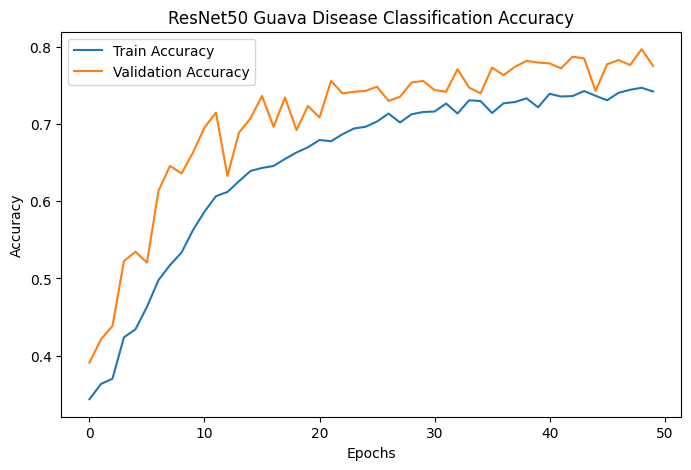

In [3]:
# ============================================================
# 🍃 Guava Disease Classification using ResNet50 (Auto Class Detection + CUDA)
# ============================================================

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

# ============================================================
# ✅ Check for CUDA / GPU
# ============================================================
print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU is available: {gpus}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU detected — running on CPU. Check CUDA & cuDNN installation.")

# ============================================================
# Dataset Paths (Update these paths)
# ============================================================
train_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\GuavaDiseaseDataset\train"
val_dir   = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\GuavaDiseaseDataset\val"
test_dir  = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\GuavaDiseaseDataset\test"

# ============================================================
# Parameters
# ============================================================
img_size = (224, 224)
batch_size = 32

# ============================================================
# Data Generators
# ============================================================
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

# Automatically detect number of classes
num_classes = len(train_gen.class_indices)
print(f"\n✅ Detected {num_classes} classes: {list(train_gen.class_indices.keys())}")

# ============================================================
# Model Definition — ResNet50
# ============================================================
tf.keras.backend.clear_session()

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze convolutional base
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ============================================================
# Compile Model
# ============================================================
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# Callbacks
# ============================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_resnet50_guava_disease.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

# ============================================================
# Training
# ============================================================
with tf.device('/GPU:0' if gpus else '/CPU:0'):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=[early_stop, checkpoint, reduce_lr],
        verbose=1
    )

# ============================================================
# Evaluation
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")

# ============================================================
# Save Final Model
# ============================================================
model.save("resnet50_guava_disease_final.h5")
print("💾 Model saved as 'resnet50_guava_disease_final.h5'")

# ============================================================
# Plot Accuracy Curves
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('ResNet50 Guava Disease Classification Accuracy')
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.6786 - loss: 0.7754

🎯 Test Accuracy: 67.86%
🧮 Test Loss: 0.7754
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step

📊 Classification Report:

                         precision    recall  f1-score   support

  Anthracnose_augmented       0.55      0.79      0.65       156
    fruit_fly_augmented       0.83      0.44      0.58       131
healthy_guava_augmented       0.78      0.75      0.76       186

               accuracy                           0.68       473
              macro avg       0.72      0.66      0.66       473
           weighted avg       0.72      0.68      0.67       473



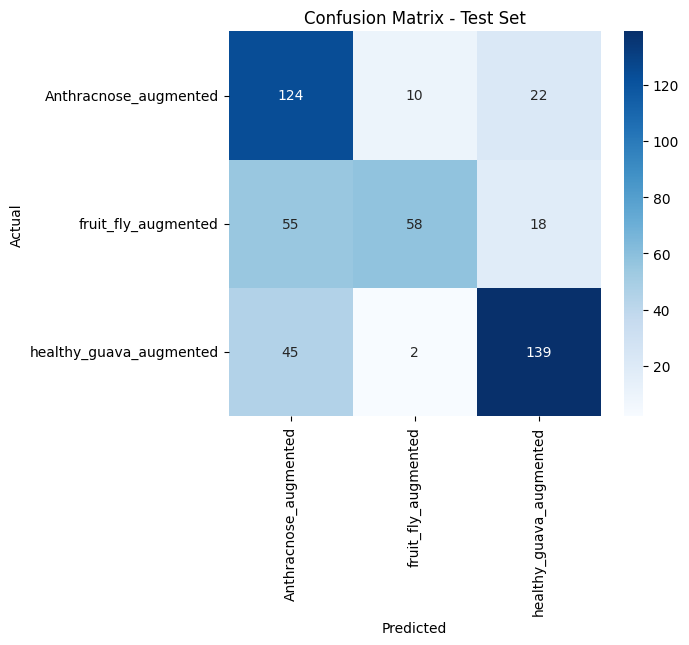

✅ Final Test Accuracy Score: 67.86%


In [4]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns

# ============================================================
# ✅ Evaluate and Get Predictions on Test Set
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n🎯 Test Accuracy: {test_acc*100:.2f}%")
print(f"🧮 Test Loss: {test_loss:.4f}")

# Predict class probabilities
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# ============================================================
# ✅ Classification Report
# ============================================================
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=list(test_gen.class_indices.keys())))

# ============================================================
# ✅ Confusion Matrix
# ============================================================
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(test_gen.class_indices.keys()), 
            yticklabels=list(test_gen.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

# ============================================================
# ✅ Overall Accuracy Score
# ============================================================
acc = accuracy_score(y_true, y_pred_classes)
print(f"✅ Final Test Accuracy Score: {acc*100:.2f}%")

In [5]:
# ============================================================
# ✅ Final Train & Validation Scores
# ============================================================
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\n📈 Final Training Results:")
print(f"🟩 Train Accuracy: {final_train_acc*100:.2f}%")
print(f"🟩 Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"🔹 Train Loss: {final_train_loss:.4f}")
print(f"🔹 Validation Loss: {final_val_loss:.4f}")


📈 Final Training Results:
🟩 Train Accuracy: 74.22%
🟩 Validation Accuracy: 77.54%
🔹 Train Loss: 0.6736
🔹 Validation Loss: 0.7057
